In [1]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [2]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from models import *
from mpl_toolkits.axes_grid1 import make_axes_locatable
from src.NonstationarityTest import marginalize_likelihood_1d, marginalize_likelihood_2d, _build_log_likelihood_grid
from src.NonstationarityTest import prior_E, prior_1d

%load_ext autoreload
%autoreload 2

# NSMap Demonstration (Figure 1)
Code for generating Figure 1. To regenerate the underlying data, run the following 3 blocks. To just recreate the figure with pre-generated data, run the subsequent two.

In [3]:
names = ["Stationary\nLinear", "Nonstationary\nLinear", "Stationary\nNonlinear", "Nonstationary\nNonlinear"]

In [4]:
stuff_dict = {}

linear = generate_linear()
linear_nonstat = generate_linear_nonstat()
logistic = generate_logistic()
logistic_nonstat = generate_logistic_nonstat()
food_chain = generate_food_chain()
food_chain_nonstat = generate_food_chain_nonstat()

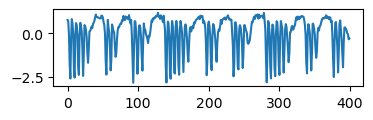

In [7]:
plt.figure(figsize=(4,1))
plt.plot(food_chain)

In [6]:
with open(os.path.join(experiment_directory, "parameters_round1.json"), "r") as f:
    params = json.load(f)

In [7]:
N_replicates = params["N_replicates"]

In [8]:
t = np.linspace(0, 1, 200)
tau = 1
data = (linear, t, tau)

E_range = [0, 9] # params["E_range"]
embedding_dimensions = np.arange(E_range[0], E_range[1])

lambda1 = params["lambda1"]
lambda2 = params["lambda2"]
p = params["p"]

experiment_params = params["experiments"][2]["parameters"]  # Nonstationary Nonlinear

theta_range = experiment_params["theta_range"]
delta_range = experiment_params["delta_range"]

resolution = params["resolution"]

In [52]:
# Takes about 4 minutes to run:

def ns_map_s_map_comparison(time_series, tx, E_range, theta_grid, delta_grid, lambda1, lambda2, p):
    ############################################################################

    # 
    log_likelihoods_ns, E_vals, theta_vals, delta_vals = _build_log_likelihood_grid(time_series, tx, E_range, theta_grid, delta_grid, 1)
    log_likelihoods_s, E_vals, theta_vals, _ = _build_log_likelihood_grid(time_series, tx, E_range, theta_grid, None, 1, delta_is_zero=True)

    # Construct Prior
    prior_E_vals = np.array([prior_E(E, p) for E in E_vals])
    prior_theta_vals = np.array([prior_1d(th, lambda1) for th in theta_vals])
    prior_delta_vals = np.array([prior_1d(dl, lambda2) for dl in delta_vals])
    prior_grid_ns = prior_E_vals[:, None, None] * prior_theta_vals[None, :, None] * prior_delta_vals[None, None, :]
    prior_grid_s = prior_E_vals[:, None] * prior_theta_vals[None, :]

    # Localization
    mega_max_log_likelihood = np.max([np.max(log_likelihoods_s), np.max(log_likelihoods_ns)])

    likelihoods_ns = np.exp(log_likelihoods_ns - mega_max_log_likelihood)
    likelihoods_s = np.exp(log_likelihoods_s - mega_max_log_likelihood)

    posterior_grid_ns = likelihoods_ns * prior_grid_ns
    posterior_grid_s = likelihoods_s.squeeze(2) * prior_grid_s

    # Marginalize
    marginalize_likelihood_s = np.zeros(posterior_grid_ns.shape[0])
    marginalize_likelihood_ns = np.zeros(posterior_grid_ns.shape[0])

    for i in range(posterior_grid_ns.shape[0]):
        # Trapezoidal integration over theta and delta for NSMap using np.trapezoid
        marginalize_likelihood_ns[i] = np.trapezoid(
            np.trapezoid(posterior_grid_ns[i], x=delta_vals, axis=1), x=theta_vals, axis=0)
        # Trapezoidal integration over theta for SMap using np.trapezoid
        marginalize_likelihood_s[i] = np.trapezoid(posterior_grid_s[i], x=theta_vals, axis=0)

    return marginalize_likelihood_ns, marginalize_likelihood_s, E_vals

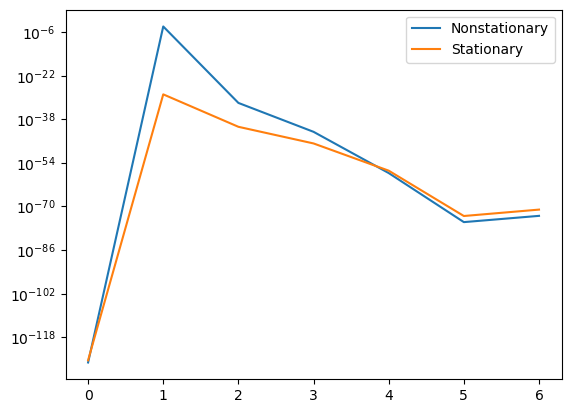

In [69]:
plt.plot(E_vals, marginalize_likelihood_ns, label="Nonstationary")
plt.plot(E_vals, marginalize_likelihood_s, label="Stationary")
plt.legend()
plt.yscale("log")

In [53]:
for (name, experiment, series) in zip(names, params["experiments"], [linear, linear_nonstat, logistic, logistic_nonstat]):

    theta_range = experiment["parameters"]["theta_range"]
    delta_range = experiment["parameters"]["delta_range"]

    tx = np.linspace(0, 1, 200)

    theta_grid = np.linspace(theta_range[0], theta_range[1], resolution)
    delta_grid = np.linspace(delta_range[0], delta_range[1], resolution)

    print(f"{name}: {linear.shape}, {linear_nonstat.shape}, {logistic.shape}, {logistic_nonstat.shape}")

    data = (series, t, tau)

    marginal_likelihood_ns, marginal_likelihood_s, E_vals = ns_map_s_map_comparison(
        series, tx, E_range, theta_grid, delta_grid, lambda1, lambda2, p)

    stuff_dict[name] = (series, t, E_vals, marginal_likelihood_s, marginal_likelihood_ns)

Stationary
Linear: (200, 1), (200, 1), (200, 1), (200, 1)
Nonstationary
Linear: (200, 1), (200, 1), (200, 1), (200, 1)
Stationary
Nonlinear: (200, 1), (200, 1), (200, 1), (200, 1)
Nonstationary
Nonlinear: (200, 1), (200, 1), (200, 1), (200, 1)


In [38]:
import pickle

with open("stuff_dict.pkl", "wb") as f:
    pickle.dump(stuff_dict, f)

In [24]:
import pickle

with open("../../stuff_dict.pkl", "rb") as f:
    stuff_dict = pickle.load(f)

In [72]:
# Data on the prior over E

embedding_dimension_prior = [prior_E(E , p) for E in embedding_dimensions]

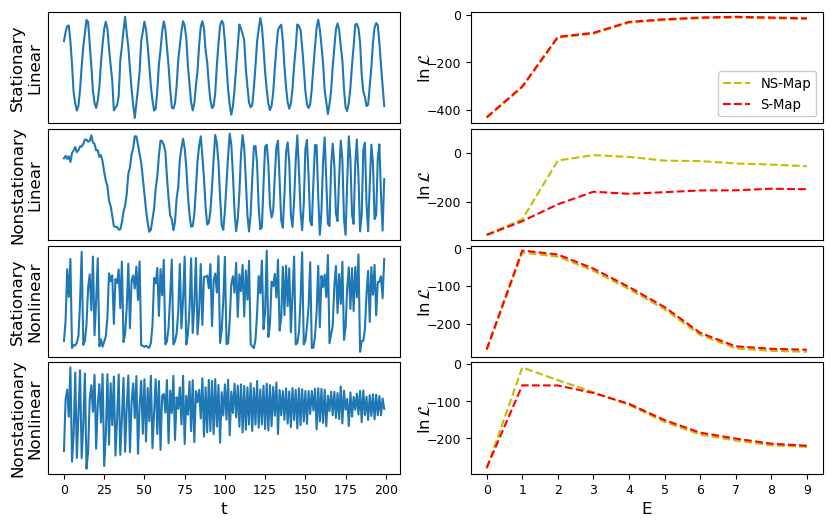

In [54]:
vfig, vax = plt.subplots(4, 2, figsize=(10,6))
fsize = 12
text_padding = 0.01
label_pad = -0.15

E_range = range(params["E_range"][0]+1, params["E_range"][1]+1)

labelnames = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)']

# for series, ax in zip((statlin, nonstatlin, statlog, nonstatlog), vax.flatten()):
for ax_row, i in zip(vax[:4], np.arange(4)):
    
    series, t, E_range, likelihood_s, likelihood_ns  = stuff_dict[names[i]]

    ax_row[0].plot(series)
    ax_row[0].set_yticks([])
    ax_row[0].set_ylabel(names[i], size=fsize)
    ax_row[0].tick_params(axis='both', which='major', labelsize=fsize * 3 / 4)
    if i == 3:
        ax_row[0].set_xlabel(r"t", size=fsize)
    else:
        ax_row[0].set_xticks([])

    minLine = (np.log(likelihood_s) * 0)+min(min(np.log(likelihood_s)),min(np.log(likelihood_ns))) 

    ax_row[1].plot(E_range, np.log(likelihood_ns), "y--", label=r"NS-Map")
    # ax_row[1].fill_between(E_range, np.log(likelihood_ns), minLine, color = "yellow")
    ax_row[1].plot(E_range, np.log(likelihood_s), "r--", label=r"S-Map")
    # ax_row[1].fill_between(E_range, np.log(likelihood_s), minLine, color="orange")
    ax_row[1].set_xticks(E_range)
    if i != 3:
        ax_row[1].set_xticks([])
    else:
        ax_row[1].set_xlabel("E", size = fsize)
    if i == 1:
        ax_row[1].set_ylim([minLine[0]-20, 100])
    ax_row[1].tick_params(axis='both', which='major', labelsize=fsize * 3 / 4)

    ax_row[1].text(label_pad, 0.5, r"$\ln\mathcal{L}$", size=fsize, rotation = 90, 
            horizontalalignment="left", verticalalignment="center",
            transform=ax_row[1].transAxes)

    if i == 0:
        ax_row[1].legend(fontsize = fsize - 2.5, framealpha=1)

    """
    divider = make_axes_locatable(ax_row[1])
    bax = divider.append_axes('top', size='100%', pad=0)
    
    # bax.plot(E_range, table[:,0], label=r"$\hat{\delta}$", color="green")
    # bax.plot(E_range, table[:,3], label=r"$\hat{\theta}$", color="silver")
    bax.set_xticks([])
    bax.tick_params(axis='both', which='major', labelsize=fsize * 3 / 4)
    
    
    ax_row[0].text(text_padding, 1-text_padding*2, f"{labelnames[3*i]}", size=fsize, fontweight="bold",
           horizontalalignment="left", verticalalignment="top",
           transform=ax_row[0].transAxes)
    bax.text(text_padding, 1-text_padding*4, f"{labelnames[3*i+1]}", size=fsize, fontweight="bold",
           horizontalalignment="left",verticalalignment="top",
           transform=bax.transAxes)
    bax.text(label_pad, 0.5, r"Parameter", size=fsize,
           horizontalalignment="left", verticalalignment="center", rotation = 90,
           transform=bax.transAxes)
    ax_row[1].text(text_padding, 1-text_padding*4, f"{labelnames[3*i+2]}", size=fsize, fontweight="bold",
           horizontalalignment="left",verticalalignment="top",
           transform=ax_row[1].transAxes)
    ax_row[1].text(label_pad, 0.5, r"$\ln\mathcal{L}$", size=fsize, rotation = 90, 
           horizontalalignment="left",verticalalignment="center",
           transform=ax_row[1].transAxes)

    if i == 0:
        bax.legend(fontsize = fsize - 2.5, framealpha=1)
        bax.set_yticks([0])
        ax_row[1].legend(fontsize = fsize - 2.5, framealpha=1)
    """
        
plt.subplots_adjust(wspace=0.2,
                    hspace=0.05)
plt.savefig(f"../../figures_eps/Figure_1.eps", format="eps", bbox_inches="tight", transparent=False)

# Delta vs Theta (Figure 2)

In [3]:
# fill with data of results for Hastings Powell and Logistic in Round 2
# l_data = np.loadtxt("simulation_results_final\logistic_NSMap_vs_DLM.csv",delimiter=',')
# fc_data = np.loadtxt("simulation_results_final\hastings_powell_NSMap_vs_DLM.csv",delimiter=',')
# lin_data = np.loadtxt("simulation_results_final\linear_NSMap_vs_DLM.csv",delimiter=',')
lin_stat = np.loadtxt("linear.csv", delimiter=',', skiprows=1)
lin_nonstat = np.loadtxt("linear_nonstat.csv", delimiter=',', skiprows=1)
l_stat = np.loadtxt("logistic.csv", delimiter=',', skiprows=1)
l_nonstat = np.loadtxt("logistic_nonstat.csv", delimiter=',', skiprows=1)
fc_stat = np.loadtxt("food_chain.csv", delimiter=',', skiprows=1)
fc_nonstat = np.loadtxt("food_chain_nonstat.csv", delimiter=',', skiprows=1)

"""
l_nonstat = np.log(l_data[l_data[:,0] == 1][:,1:3]+1)
l_stat = np.log(l_data[l_data[:,0] == 0][:,1:3]+1)
fc_nonstat = np.log(fc_data[fc_data[:,0] == 1][:,1:3]+1)
fc_stat = np.log(fc_data[fc_data[:,0] == 0][:,1:3]+1)
lin_nonstat = np.log(lin_data[lin_data[:,0] == 1][:,1:3]+1)
lin_stat = np.log(lin_data[lin_data[:,0] == 0][:,1:3]+1)
"""

'\nl_nonstat = np.log(l_data[l_data[:,0] == 1][:,1:3]+1)\nl_stat = np.log(l_data[l_data[:,0] == 0][:,1:3]+1)\nfc_nonstat = np.log(fc_data[fc_data[:,0] == 1][:,1:3]+1)\nfc_stat = np.log(fc_data[fc_data[:,0] == 0][:,1:3]+1)\nlin_nonstat = np.log(lin_data[lin_data[:,0] == 1][:,1:3]+1)\nlin_stat = np.log(lin_data[lin_data[:,0] == 0][:,1:3]+1)\n'

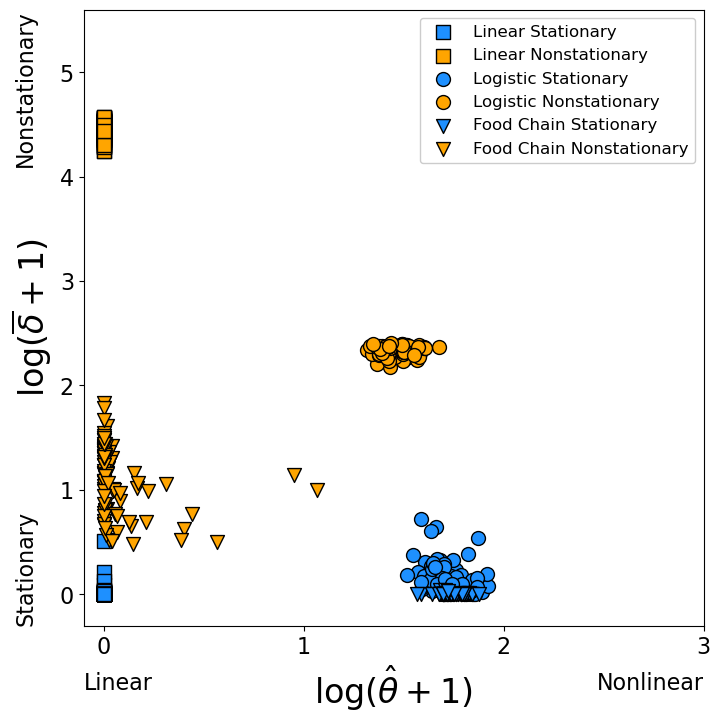

In [13]:
size = 100
alpha = 1
dither = 0.02
fontsize_ticks = 16
fontsize_legend = 12
fontsize_axis = 24
fontsize_text = 16
text_padding = -0.075

dithering = lambda: rand.normal(0,dither,size=N_replicates)

dvt_fig, dvt_ax = plt.subplots(1, figsize=(8,8))
dvt_ax.set_xlabel(r"$\log(\hat{\theta}+1)$",fontsize=fontsize_axis)
dvt_ax.set_ylabel(r"$\log(\overline{\delta}+1)$",fontsize=fontsize_axis)
# dvt_ax.set_xticks([0,1.75])
dvt_ax.text(text_padding, 1, "Nonstationary", size=fontsize_text, rotation=90, 
            horizontalalignment="right", verticalalignment="top",
            transform=dvt_ax.transAxes)
dvt_ax.text(text_padding, 0, "Stationary", size=fontsize_text, rotation=90,
           horizontalalignment="right",verticalalignment="bottom",
           transform=dvt_ax.transAxes)
dvt_ax.text(0, text_padding, "Linear", size=fontsize_text,
           horizontalalignment="left",verticalalignment="top",
           transform=dvt_ax.transAxes)
dvt_ax.text(1, text_padding, "Nonlinear", size=fontsize_text,
           horizontalalignment="right",verticalalignment="top",
           transform=dvt_ax.transAxes)

dvt_ax.scatter(np.log(lin_stat[:,4]+1), np.log(lin_stat[:,5]+1), 
               c="dodgerblue",marker="s", s=size, edgecolors="black", 
               label="Linear Stationary", alpha=alpha)
dvt_ax.scatter(np.log(lin_nonstat[:,4]+1), np.log(lin_nonstat[:,5]+1), 
               c="orange",marker="s", s=size, edgecolors="black", 
               label="Linear Nonstationary", alpha=alpha)
dvt_ax.scatter(np.log(l_stat[:,4]+1), np.log(l_stat[:,5]+1), 
               c="dodgerblue", s=size, edgecolors="black", 
               label="Logistic Stationary", alpha=alpha)
dvt_ax.scatter(np.log(l_nonstat[:,4]+1), np.log(l_nonstat[:,5]+1), 
               c="orange", s=size, edgecolors="black", 
               label="Logistic Nonstationary", alpha=alpha)
dvt_ax.scatter(np.log(fc_stat[:,4]+1), np.log(fc_stat[:,5]+1), 
               c="dodgerblue",marker="v", s=size, edgecolors="black", 
               label="Food Chain Stationary", alpha=alpha)
dvt_ax.scatter(np.log(fc_nonstat[:,4]+1), np.log(fc_nonstat[:,5]+1), 
               c="orange",marker="v", s=size, edgecolors="black", 
               label="Food Chain Nonstationary", alpha=alpha)

dvt_ax.set_xlim([-0.1,3])
dvt_ax.set_ylim([-0.3,5.6])
dvt_ax.set_xticks([0,1,2,3])

plt.xticks(fontsize=fontsize_ticks, rotation=0)
plt.yticks(fontsize=fontsize_ticks, rotation=0)
plt.legend(prop={"size":fontsize_legend}, framealpha=1)
plt.savefig(f"../../figures_eps/round1_results/Figure_2.eps", format="eps", bbox_inches="tight", transparent=False)

## NSMap vs DLM (Figure 3)

In [14]:
evidence_to_probability = lambda ev: (10 ** (ev / 10)) / ((10 ** (ev / 10)) + 1)

/tmp/ipykernel_299272/3348030117.py:32: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_dlm[i], y_dlm[i], color=scatter_colors[0], marker='+', s=size, alpha=1, label="DLM" if i==0 else None, edgecolors='black', linewidths=0.7)
/tmp/ipykernel_299272/3348030117.py:33: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_nsmap[i], y_nsmap[i], marker='x', color=scatter_colors[1], s=size, alpha=1, label="NS-Map" if i==0 else None, edgecolors='black', linewidths=0.7)


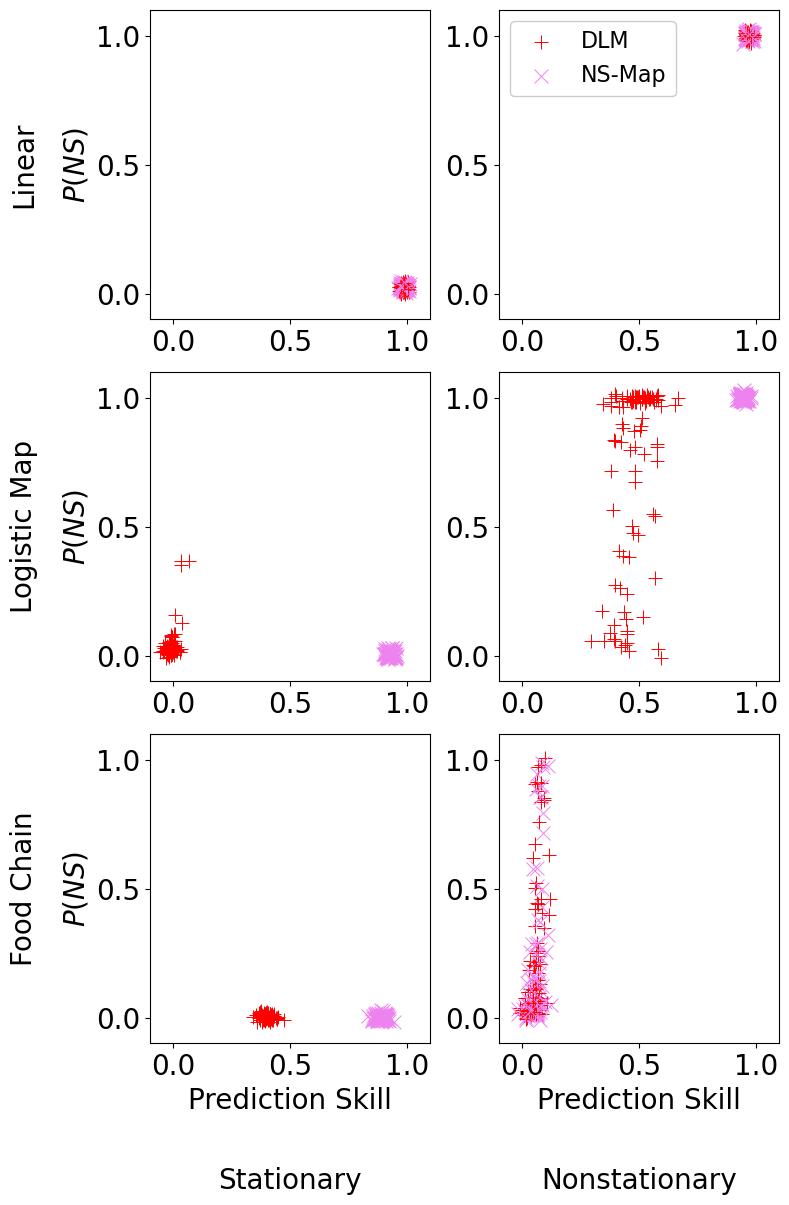

In [15]:
import seaborn as sns
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable
vfig, vax = plt.subplots(3,2,figsize=(8,12))
B = 40
size = 1e2  # Make points much smaller
fontsize_axis = 20
fontsize_ticks = 20
fontsize_text = 20

text_padding_y = -0.4
text_padding_x = -0.4

marginal_kde_bandwidth = 1e0

dithering = lambda : rand.normal(0, 0.01, N_replicates)
evidence_to_probability = lambda ev: (10 ** (ev / 10)) / ((10 ** (ev / 10)) + 1)

scatter_colors = ["red", "violet"]  # DLM, NS-Map

for m, model in enumerate(["lin", "l", "fc"]):
    for s, status in enumerate(["stat", "nonstat"]):
        data = locals()[model + "_" + status]
        x_dlm = data[:,-1] + dithering()
        y_dlm = evidence_to_probability(data[:,2]) + dithering()
        x_nsmap = data[:,-2] + dithering()
        y_nsmap = evidence_to_probability(data[:,0]) + dithering()
        ax = vax[m,min(1,s)]
        # Alternate scatter points for DLM and NS-Map
        n_points = min(len(x_dlm), len(x_nsmap))
        for i in range(n_points):
            ax.scatter(x_dlm[i], y_dlm[i], color=scatter_colors[0], marker='+', s=size, alpha=1, label="DLM" if i==0 else None, edgecolors='black', linewidths=0.7)
            ax.scatter(x_nsmap[i], y_nsmap[i], marker='x', color=scatter_colors[1], s=size, alpha=1, label="NS-Map" if i==0 else None, edgecolors='black', linewidths=0.7)
        # If one array is longer, plot remaining points
        for i in range(n_points, len(x_dlm)):
            ax.scatter(x_dlm[i], y_dlm[i], color=scatter_colors[0], marker='+', s=size, alpha=1, edgecolors='black', linewidths=0.7)
        for i in range(n_points, len(x_nsmap)):
            ax.scatter(x_nsmap[i], y_nsmap[i], marker='x', color=scatter_colors[1], s=size, alpha=1, edgecolors='black', linewidths=0.7)
        """
        # Marginal KDEs
        divider = make_axes_locatable(ax)
        ax_marg_x = divider.append_axes("bottom", size="15%", pad=0.0, sharex=ax)
        ax_marg_y = divider.append_axes("left", size="15%", pad=0.0, sharey=ax)
        # DLM marginal KDEs
        sns.kdeplot(x_dlm, ax=ax_marg_x, color=scatter_colors[0], fill=True, linewidth=2, bw_method=marginal_kde_bandwidth)
        sns.kdeplot(y_dlm, ax=ax_marg_y, color=scatter_colors[0], fill=True, linewidth=2, bw_method=marginal_kde_bandwidth)
        # NS-Map marginal KDEs
        sns.kdeplot(x_nsmap, ax=ax_marg_x, color=scatter_colors[1], fill=True, linewidth=2, bw_method=marginal_kde_bandwidth)
        sns.kdeplot(y_nsmap, ax=ax_marg_y, color=scatter_colors[1], fill=True, linewidth=2, bw_method=marginal_kde_bandwidth)
        ax_marg_x.axis('off')
        ax_marg_y.axis('off')
        """

        ax.set_xlim([-0.1, 1.1])
        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_ylim([-0.1, 1.1])
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.tick_params(axis='both',which='major', labelsize=fontsize_ticks)
        

for i in range(3):
    vax[i,0].set_ylabel(r"$P(NS)$",size=fontsize_axis)
for i in range(2):
    vax[2,i].set_xlabel(r"Prediction Skill",size=fontsize_axis)

vax[0,0].text(text_padding_y, 0.5, "Linear", rotation=90, verticalalignment="center", horizontalalignment="right", transform=vax[0,0].transAxes,size=fontsize_text)
vax[1,0].text(text_padding_y, 0.5, "Logistic Map", rotation=90, verticalalignment="center", horizontalalignment="right", transform=vax[1,0].transAxes,size=fontsize_text)
vax[2,0].text(text_padding_y, 0.5, "Food Chain", rotation=90, verticalalignment="center", horizontalalignment="right", transform=vax[2,0].transAxes,size=fontsize_text)
vax[2,0].text(0.5, text_padding_x, "Stationary", verticalalignment="top", horizontalalignment="center", transform=vax[2,0].transAxes,size=fontsize_text)
vax[2,1].text(0.5, text_padding_x, "Nonstationary", verticalalignment="top", horizontalalignment="center", transform=vax[2,1].transAxes,size=fontsize_text)
# vax[2,2].text(0.5, text_padding_x, "Fast Nonstationary", 
#               verticalalignment="top", horizontalalignment="center",
#               transform=vax[2,2].transAxes,size=fontsize_text)

vax[0,1].legend(fontsize=16, framealpha=1)
plt.tight_layout()
# plt.savefig("../../Figures/round1_NSMap_vs_DLM.png", dpi=300)
plt.savefig("../../figures_eps/round1_results/Figure_3.eps", format="eps", bbox_inches="tight", transparent = False)

In [22]:
# Compute the increase in forecast skill for nonlinear models from SMap to NSMap,
# averaging over all nonstationary categories

print(f"Stationary Logistic NSMap classification = {np.mean(l_stat[:,1] < 0.95)}")
print(f"Nonstationary Logistic NSMap classification = {np.mean(l_nonstat[:,1] > 0.95)}")
print(f"Stationary Logistic DLM classification = {np.mean(l_stat[:,2] < 0.95)}")
print(f"Nonstationary Logistic DLM classification = {np.mean(l_nonstat[:,2] > 0.95)}")
print(f"")
print(f"Logistic DLM r_sqrd = {np.mean(l_data[:,5])}")
print(f"Food Chain NSMap r_sqrd = {np.mean(fc_data[:,3])}")
print(f"Food Chain DLM r_sqrd = {np.mean(fc_data[:,5])}")

StationaryLogistic NSMap classification = 1.0
Nonstationary Logistic NSMap classification = 1.0


NameError: name 'l_data' is not defined

In [26]:
import numpy as np
import pandas as pd
from collections import OrderedDict

def confusion_table(true_labels, predicted_labels):
    TP = ((true_labels == 1) & (predicted_labels == 1)).sum()
    TN = ((true_labels == 0) & (predicted_labels == 0)).sum()
    FP = ((true_labels == 0) & (predicted_labels == 1)).sum()
    FN = ((true_labels == 1) & (predicted_labels == 0)).sum()
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    return OrderedDict([('TP', TP), ('TN', TN), ('FP', FP), ('FN', FN), ('Recall', recall)])

threshold = 0.95
systems = [
    ('Linear', lin_stat, lin_nonstat),
    ('Logistic', l_stat, l_nonstat),
    ('Food Chain', fc_stat, fc_nonstat)
]

for system_name, stat_data, nonstat_data in systems:
    true_labels = np.concatenate([np.zeros(len(stat_data)), np.ones(len(nonstat_data))])
    nsmap_pred = np.concatenate([stat_data[:,1], nonstat_data[:,1]]) > threshold
    dlm_pred = np.concatenate([stat_data[:,3], nonstat_data[:,3]]) > threshold

    print(f"Confusion Table for {system_name} (NSMap):")
    print(pd.DataFrame([confusion_table(true_labels, nsmap_pred)], index=['NSMap']))
    print(f"Confusion Table for {system_name} (DLM):")
    print(pd.DataFrame([confusion_table(true_labels, dlm_pred)], index=['DLM']))
    print("\n")

Confusion Table for Linear (NSMap):
       TP  TN  FP  FN  Recall
NSMap  50  50   0   0     1.0
Confusion Table for Linear (DLM):
     TP  TN  FP  FN  Recall
DLM  50  50   0   0     1.0


Confusion Table for Logistic (NSMap):
       TP  TN  FP  FN  Recall
NSMap  50  50   0   0     1.0
Confusion Table for Logistic (DLM):
     TP  TN  FP  FN  Recall
DLM  40  50   0  10     0.8


Confusion Table for Food Chain (NSMap):
       TP  TN  FP  FN  Recall
NSMap  38  50   0  12    0.76
Confusion Table for Food Chain (DLM):
     TP  TN  FP  FN  Recall
DLM  25  50   0  25     0.5




/tmp/ipykernel_24382/3030041004.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='r2', data=plot_data, ax=ax_r2, palette={"DLM": "red", "NS-Map": "purple"}, inner=None, linewidth=1.5)
/tmp/ipykernel_24382/3030041004.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='P(NS)', data=plot_data, ax=ax_r2, palette={"DLM": "red", "NS-Map": "purple"}, inner=None, linewidth=1.5, alpha=0.5)
/tmp/ipykernel_24382/3030041004.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='r2', data=plot_data, ax

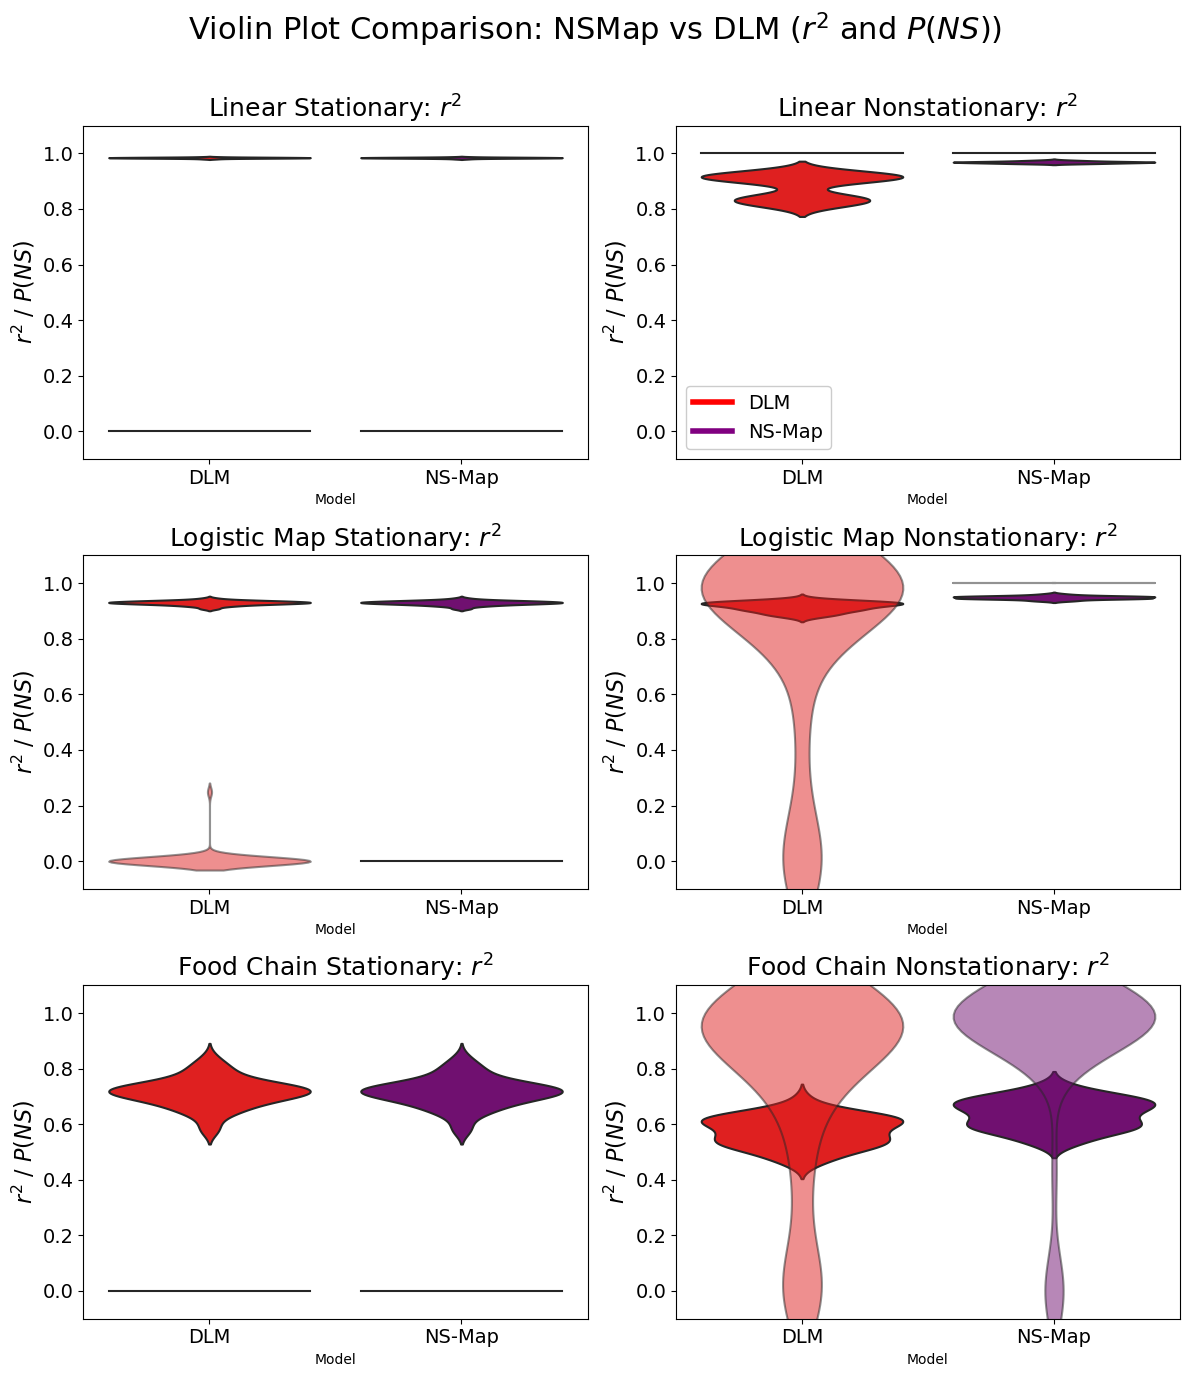

In [73]:
# Violin plot rendition of NSMap vs DLM results for r^2 and P(NS)
import matplotlib.pyplot as plt
import seaborn as sns

models = ["lin", "l", "fc"]
statuses = ["stat", "nonstat"]
model_names = ["Linear", "Logistic Map", "Food Chain"]
status_names = ["Stationary", "Nonstationary"]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

for m, model in enumerate(models):
    for s, status in enumerate(statuses):
        data = locals()[model + "_" + status]
        # DLM: r^2 is last column, P(NS) is column 3
        r2_dlm = data[:, -2]
        pns_dlm = np.maximum(data[:, 3], 0)
        # NS-Map: r^2 is last column, P(NS) is column 1
        r2_nsmap = data[:, -1]
        pns_nsmap = np.maximum(data[:, 1], 0)

        # Prepare data for violin plot
        plot_data = {
            'r2': np.concatenate([r2_dlm, r2_nsmap]),
            'P(NS)': np.concatenate([pns_dlm, pns_nsmap]),
            'Model': ["DLM"] * len(r2_dlm) + ["NS-Map"] * len(r2_nsmap)
        }

        # r^2 violin
        ax_r2 = axes[m, s]
        sns.violinplot(x='Model', y='r2', data=plot_data, ax=ax_r2, palette={"DLM": "red", "NS-Map": "purple"}, inner=None, linewidth=1.5)
        ax_r2.set_title(f"{model_names[m]} {status_names[s]}: $r^2$", fontsize=18)
        ax_r2.set_xlabel("")
        ax_r2.set_ylabel(r"$r^2$", fontsize=16)
        ax_r2.tick_params(axis='both', labelsize=14)
        ax_r2.set_ylim([-0.1, 1.1])

        # Overlay P(NS) violin on same axis, with some transparency
        sns.violinplot(x='Model', y='P(NS)', data=plot_data, ax=ax_r2, palette={"DLM": "red", "NS-Map": "purple"}, inner=None, linewidth=1.5, alpha=0.5)
        ax_r2.set_ylabel(r"$r^2$ / $P(NS)$", fontsize=16)

        # Add legend manually
        handles = [plt.Line2D([0], [0], color='red', lw=4, label='DLM'),
                   plt.Line2D([0], [0], color='purple', lw=4, label='NS-Map')]
        if m == 0 and s == 1:
            ax_r2.legend(handles=handles, fontsize=14, framealpha=1)

plt.suptitle("Violin Plot Comparison: NSMap vs DLM ($r^2$ and $P(NS)$)", fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig("../figures_eps/round1_results/Figure_3_violin.eps", format="eps", bbox_inches="tight", transparent=False)
plt.show()

# Equation

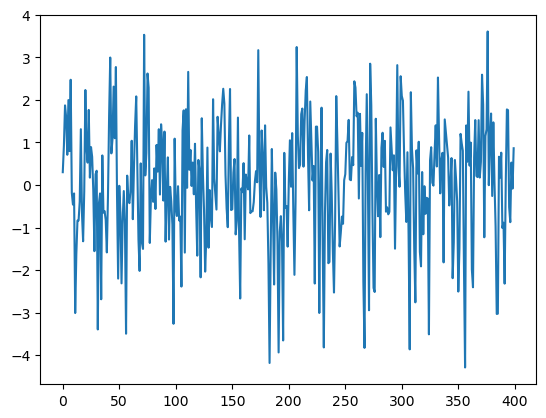

In [3]:
import experiments.simulated_round_1.models
import src.NSMap as ns

Xr = experiments.simulated_round_1.models.generate_food_chain_nonstat()

plt.plot(Xr)

In [7]:
E = 5
tau = 1
theta = 1
delta = 5 # 1e0

tx = np.linspace(0, 1, len(Xr))

Xemb_ns, Y, tx = ns.delayEmbed(Xr, E, tau, t=tx)
Yhat_ns = ns.leaveOneOut(Xemb_ns, Y, tx, theta, delta)
ss_res_ns = np.sum((Y.flatten() - Yhat_ns.flatten())**2)
ss_tot_ns = np.sum((Y.flatten() - np.mean(Y))**2)
prediction_skill_ns = 1 - ss_res_ns / ss_tot_ns if ss_tot_ns > 0 else np.nan

print(prediction_skill_ns)

0.11301338718208276


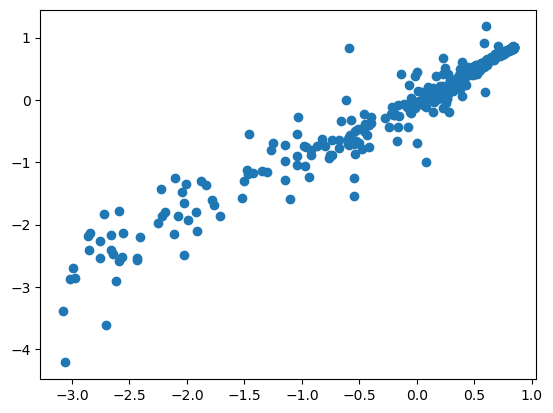

In [33]:
plt.scatter(Y, Yhat_ns)

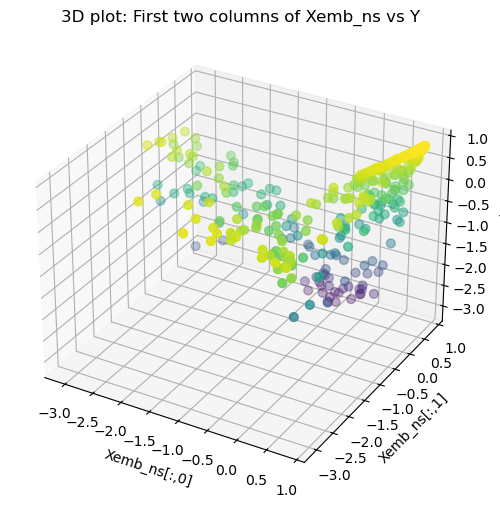

In [16]:
# 3D plot of the first two columns of Xemb_ns against Y
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xemb_ns[:,0], Xemb_ns[:,1], Y.flatten(), c=Y.flatten(), cmap='viridis', s=40)
ax.set_xlabel('Xemb_ns[:,0]')
ax.set_ylabel('Xemb_ns[:,1]')
ax.set_zlabel('Y')
ax.set_title('3D plot: First two columns of Xemb_ns vs Y')
plt.show()